# Análisis Exploratorio de Datos (EDA) - Cancelación de Reservas

1. **Entender su estructura**: Dimensiones, tipos de columnas y valores faltantes.
2. **Estudiar la variable objetivo**: Identificar si hay desbalance de clases (lo cual afectará la elección de métricas).
3. **Descubrir relaciones y patrones**: Visualizar qué variables influyen más en las cancelaciones.
4. **Identificar riesgos críticos**: Como la **fuga de datos (Target Leakage)**, que arruinaría nuestro modelo en producción.

In [1]:
# Importar librerías de manipulación de datos y visualización
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Añadir directorio raíz al PATH para poder importar src si es necesario
sys.path.append(str(Path.cwd().parent))

# Configurar estilo de los gráficos para que sean estéticos y premium
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Carga del Dataset

Cargamos el archivo CSV original. Usaremos las rutas definidas de forma centralizada en nuestro sistema de configuración (config.py)

In [2]:
from src.config import RAW_DATA_PATH, TARGET_COL

print(f"Cargando datos desde: {RAW_DATA_PATH}")
df = pd.read_csv(RAW_DATA_PATH)
print(f"¡Cargado con éxito! Dimensiones: {df.shape[0]:,} filas y {df.shape[1]} columnas.")

Cargando datos desde: C:\Users\Joakamakaka\Desktop\machine-learning-project\data\raw\dataset_practica_final.csv
¡Cargado con éxito! Dimensiones: 119,390 filas y 32 columnas.


In [3]:
# Mostramos las primeras 5 filas
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Inspección Estructural y Valores Nulos

Comprobamos si hay valores nulos que debamos rellenar más adelante.

In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# Analizar valores nulos por columna
missing_values = df.isnull().sum()
missing_percent = 100 * missing_values / len(df)
missing_table = pd.concat(
    [missing_values, missing_percent], axis=1, keys=["Valores Nulos", "% del Total"]
)
missing_table = missing_table[missing_table["Valores Nulos"] > 0].sort_values(
    by="Valores Nulos", ascending=False
)

print("Columnas con valores nulos detectadas:")
missing_table

Columnas con valores nulos detectadas:


,Valores Nulos,% del Total
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


> **Nota**: `company` tiene un alto porcentaje de nulos. Las reservas hechas por particulares no tienen empresa asociada, por lo que esta variable aporta mucho ruido y decidimos eliminarla. En cambio, para `agent` e `children` aplicaremos estrategias de imputación en nuestro pipeline.

## 3. Estudio de la Variable Objetivo

Nuestra variable objetivo es `is_canceled`. Si está muy desbalanceada, un modelo "tonto" que diga siempre "No Cancela" acertaría el 99% de las veces. Debemos medir y visualizar este balanceo.

In [6]:
counts = df[TARGET_COL].value_counts()
pcts = df[TARGET_COL].value_counts(normalize=True) * 100

print(f"Distribución real de {TARGET_COL}:")
for val, count in counts.items():
    label = "Cancelado (1)" if val == 1 else "No Cancelado (0)"
    print(f" - {label}: {count:,} reservas ({pcts[val]:.2f}%)")

Distribución real de is_canceled:
 - No Cancelado (0): 75,166 reservas (62.96%)
 - Cancelado (1): 44,224 reservas (37.04%)


C:\Users\Joakamakaka\AppData\Local\Temp\ipykernel_14456\3160581353.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Realizó Check-In (0)", "Canceló Reserva (1)"])


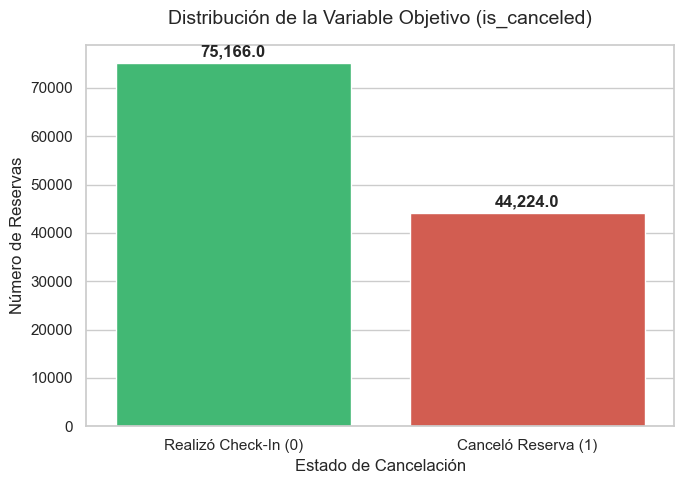

In [7]:
# Visualizar la variable objetivo con un gráfico de barras estético
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=TARGET_COL, hue=TARGET_COL, data=df, palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("Distribución de la Variable Objetivo (is_canceled)", fontsize=14, pad=15)
plt.xlabel("Estado de Cancelación", fontsize=12)
plt.ylabel("Número de Reservas", fontsize=12)
ax.set_xticklabels(["Realizó Check-In (0)", "Canceló Reserva (1)"])

# Añadir etiquetas de conteo sobre cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )
plt.tight_layout()
plt.show()


> **Nota**: Aproximadamente el **37%** de las reservas son canceladas. Existe un desbalanceo moderado. Esto significa que la métrica **Accuracy** no será del todo errónea, pero aun así el **F1-Score** podria ser mucho más adecuado para evaluar correctamente a nuestro predictor.

## 4. Visualización de Relaciones Clave (Features vs Target)

### A. ¿Influye la anticipación de la reserva (`lead_time`)?

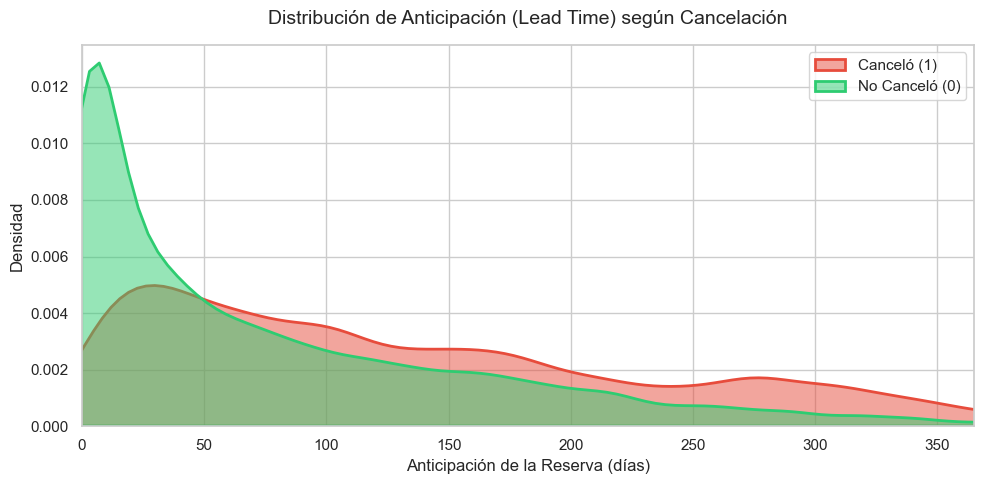

In [8]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x="lead_time",
    hue=TARGET_COL,
    fill=True,
    common_norm=False,
    palette={0: "#2ecc71", 1: "#e74c3c"},
    alpha=0.5,
    linewidth=2,
)
plt.title("Distribución de Anticipación (Lead Time) según Cancelación", fontsize=14, pad=15)
plt.xlabel("Anticipación de la Reserva (días)", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.xlim(0, 365)  # Acotamos a un año para mejor visualización
plt.legend(["Canceló (1)", "No Canceló (0)"], loc="upper right")
plt.tight_layout()
plt.show()

> **Conclusión**: Las curvas muestran claramente que **las reservas realizadas con mucha antelación (lead_time elevado) tienen una mayor densidad de cancelaciones**. Si el cliente reserva a última hora (lead_time bajo), es extremadamente probable que realice el check-in y no se llegue a cancelar.

### B. ¿Qué impacto tiene el tipo de depósito (`deposit_type`)?

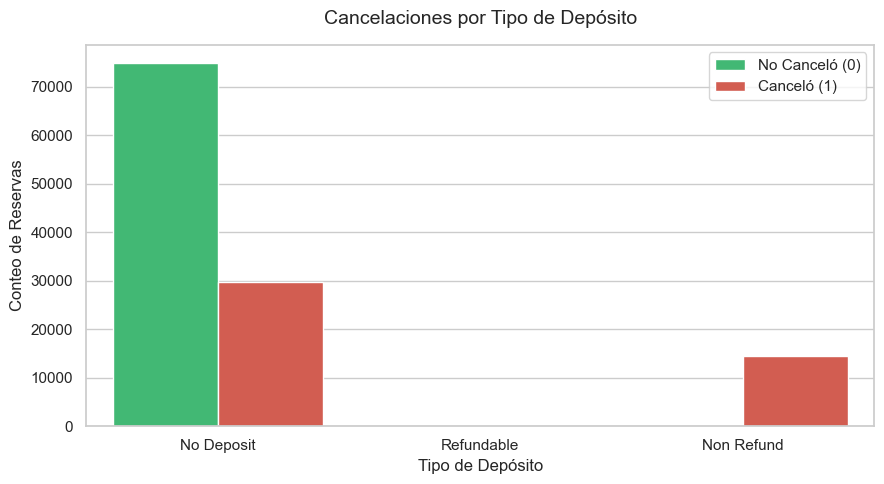

In [9]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x="deposit_type", hue=TARGET_COL, palette={0: "#2ecc71", 1: "#e74c3c"})
plt.title("Cancelaciones por Tipo de Depósito", fontsize=14, pad=15)
plt.xlabel("Tipo de Depósito", fontsize=12)
plt.ylabel("Conteo de Reservas", fontsize=12)
plt.legend(["No Canceló (0)", "Canceló (1)"], loc="upper right")
plt.tight_layout()
plt.show()

> **Hallazgo importante**: Prácticamente el 100% de ellas terminan canceladas. Esto se debe a que este tipo de depósito suele aplicarse a grupos de riesgo o reservas masivas que a veces cancelan en bloque de forma administrativa. Es una feature de mucha importancia para la prediccion futura.

### C. Mapa de Calor de Correlaciones Numéricas

Dibujamos la matriz de correlación lineal (Pearson) entre las variables numéricas y nuestro target para visualizar afinidades lineales.

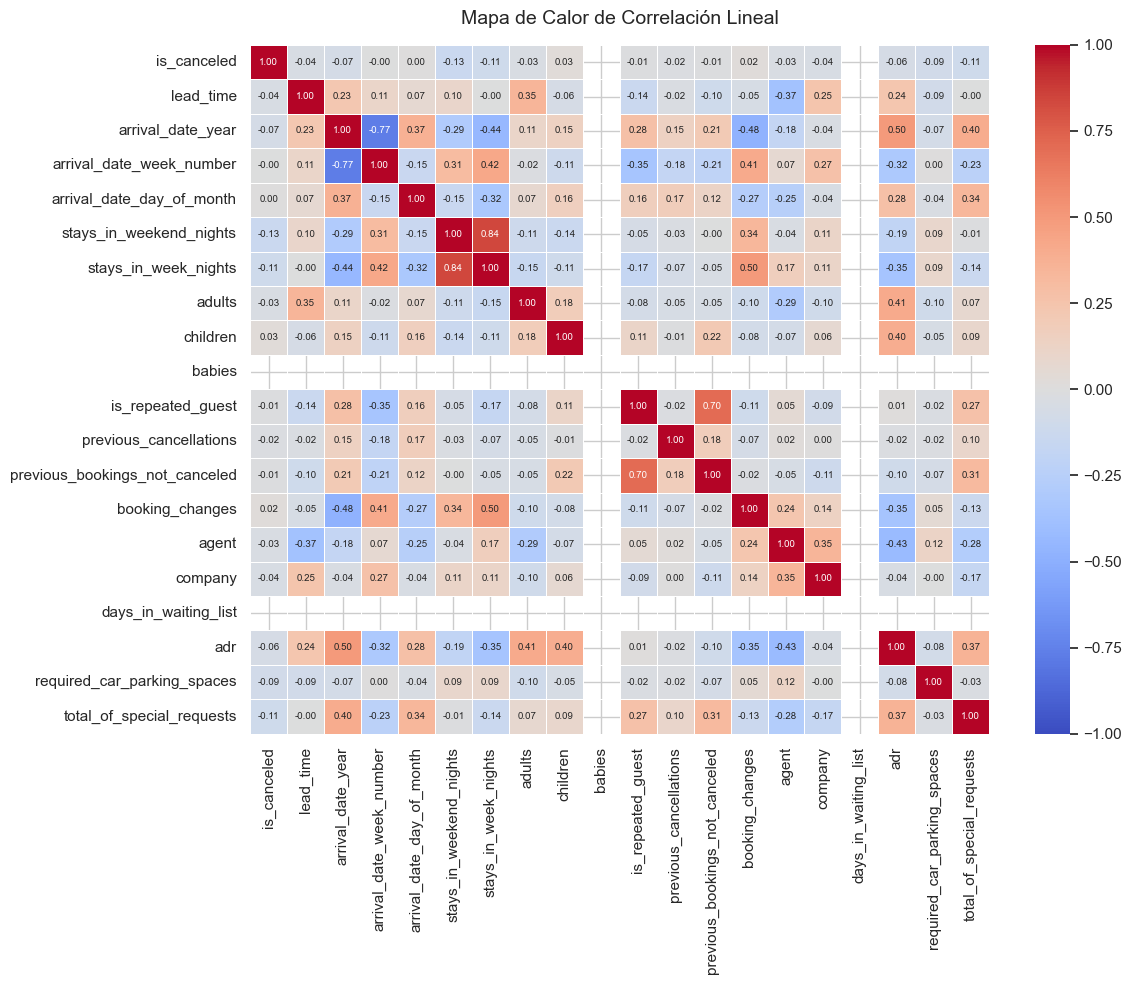

In [17]:
# Seleccionar columnas numéricas e ignorar nulas provisionalmente
num_df = df.select_dtypes(include=[np.number]).dropna()

corr_matrix = num_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", annot_kws={"size": 7}, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de Calor de Correlación Lineal", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


### D. ¿Cancela más en hoteles urbanos o de resort? (`hotel`)

> El *City Hotel* presenta una tasa de cancelación notablemente superior al *Resort Hotel*. Las reservas urbanas son más especulativas, mientras que los resorts concentran reservas vacacionales con mayor compromiso. `hotel` es, por tanto, una feature relevante para el modelo.


C:\Users\Joakamakaka\AppData\Local\Temp\ipykernel_14456\687419635.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


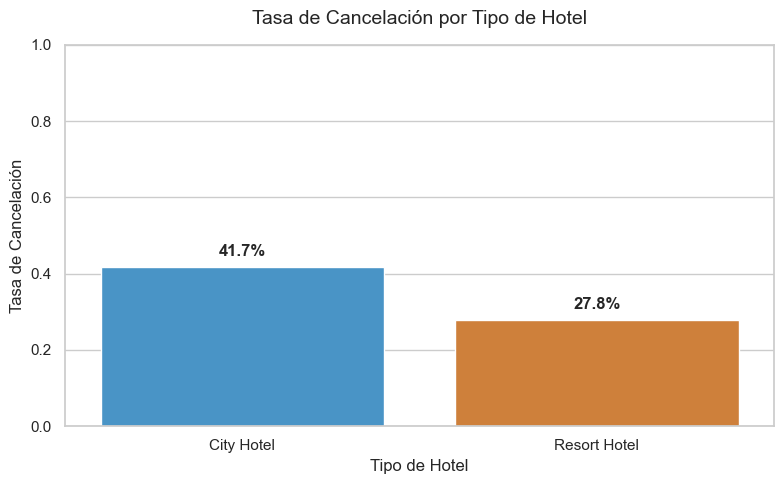

In [11]:
cancel_rate_hotel = df.groupby("hotel")[TARGET_COL].mean().reset_index()
cancel_rate_hotel.columns = ["hotel", "tasa_cancelacion"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=cancel_rate_hotel,
    x="hotel",
    y="tasa_cancelacion",
    palette=["#3498db", "#e67e22"],
)
plt.title("Tasa de Cancelación por Tipo de Hotel", fontsize=14, pad=15)
plt.xlabel("Tipo de Hotel", fontsize=12)
plt.ylabel("Tasa de Cancelación", fontsize=12)
plt.ylim(0, 1)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
        fontsize=12,
    )
plt.tight_layout()
plt.show()

### E. ¿Qué segmento de mercado concentra más cancelaciones? (`market_segment`)

> Los segmentos *Groups* y *Online TA* muestran las tasas de cancelación más elevadas, mientras que *Direct* y *Corporate* son los más fiables. Esto convierte a `market_segment` en una de las features de mayor poder predictivo para el modelo.


C:\Users\Joakamakaka\AppData\Local\Temp\ipykernel_14456\3792903943.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


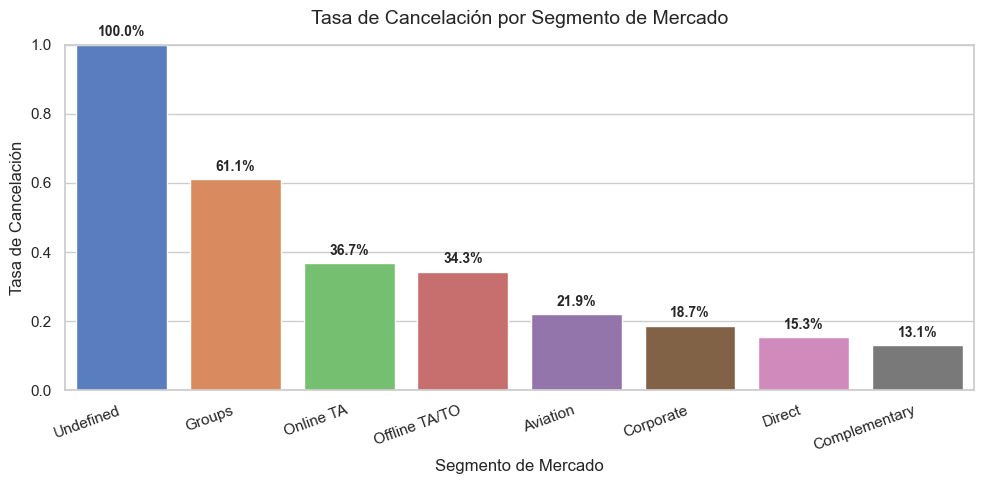

In [12]:
cancel_rate_seg = (
    df.groupby("market_segment")[TARGET_COL].mean().sort_values(ascending=False).reset_index()
)
cancel_rate_seg.columns = ["market_segment", "tasa_cancelacion"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=cancel_rate_seg,
    x="market_segment",
    y="tasa_cancelacion",
    palette="muted",
)
plt.title("Tasa de Cancelación por Segmento de Mercado", fontsize=14, pad=15)
plt.xlabel("Segmento de Mercado", fontsize=12)
plt.ylabel("Tasa de Cancelación", fontsize=12)
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

### F. ¿El tipo de cliente predice la cancelación? (`customer_type`)

> Los clientes *Transient* (reservas individuales sin contrato) representan el mayor volumen y la mayor tasa de cancelación. Los de tipo *Contract* (con acuerdo formal con el hotel) son los más fiables. Esta variable ayuda al modelo a distinguir el perfil de riesgo del cliente.

C:\Users\Joakamakaka\AppData\Local\Temp\ipykernel_14456\2778161323.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


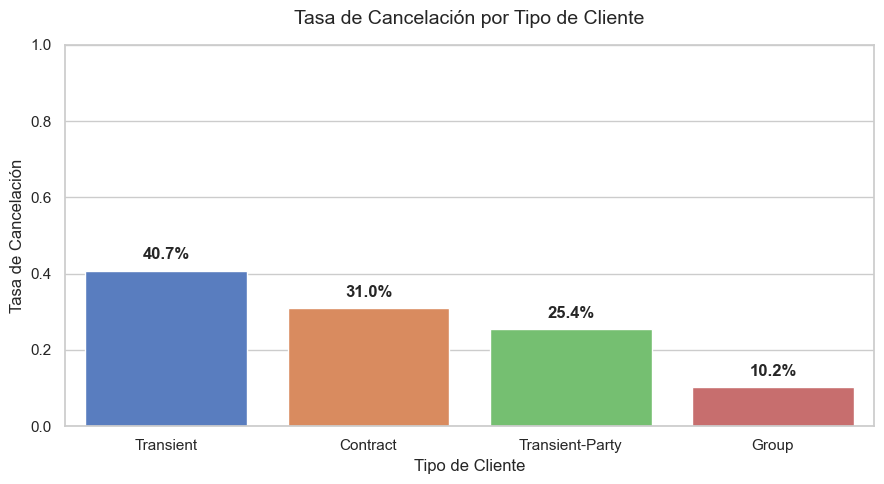

In [13]:
cancel_rate_cust = (
    df.groupby("customer_type")[TARGET_COL].mean().sort_values(ascending=False).reset_index()
)
cancel_rate_cust.columns = ["customer_type", "tasa_cancelacion"]

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=cancel_rate_cust,
    x="customer_type",
    y="tasa_cancelacion",
    palette="muted",
)
plt.title("Tasa de Cancelación por Tipo de Cliente", fontsize=14, pad=15)
plt.xlabel("Tipo de Cliente", fontsize=12)
plt.ylabel("Tasa de Cancelación", fontsize=12)
plt.ylim(0, 1)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
        fontweight="bold",
        fontsize=12,
    )
plt.tight_layout()
plt.show()

## 5. Distribuciones de Variables Numéricas Clave

Analizamos la distribución estadística de las variables numéricas más relevantes, separadas por estado de cancelación. Esto nos permite detectar **asimetría (skewness)** y **outliers**, justificando las decisiones de preprocesado del pipeline.


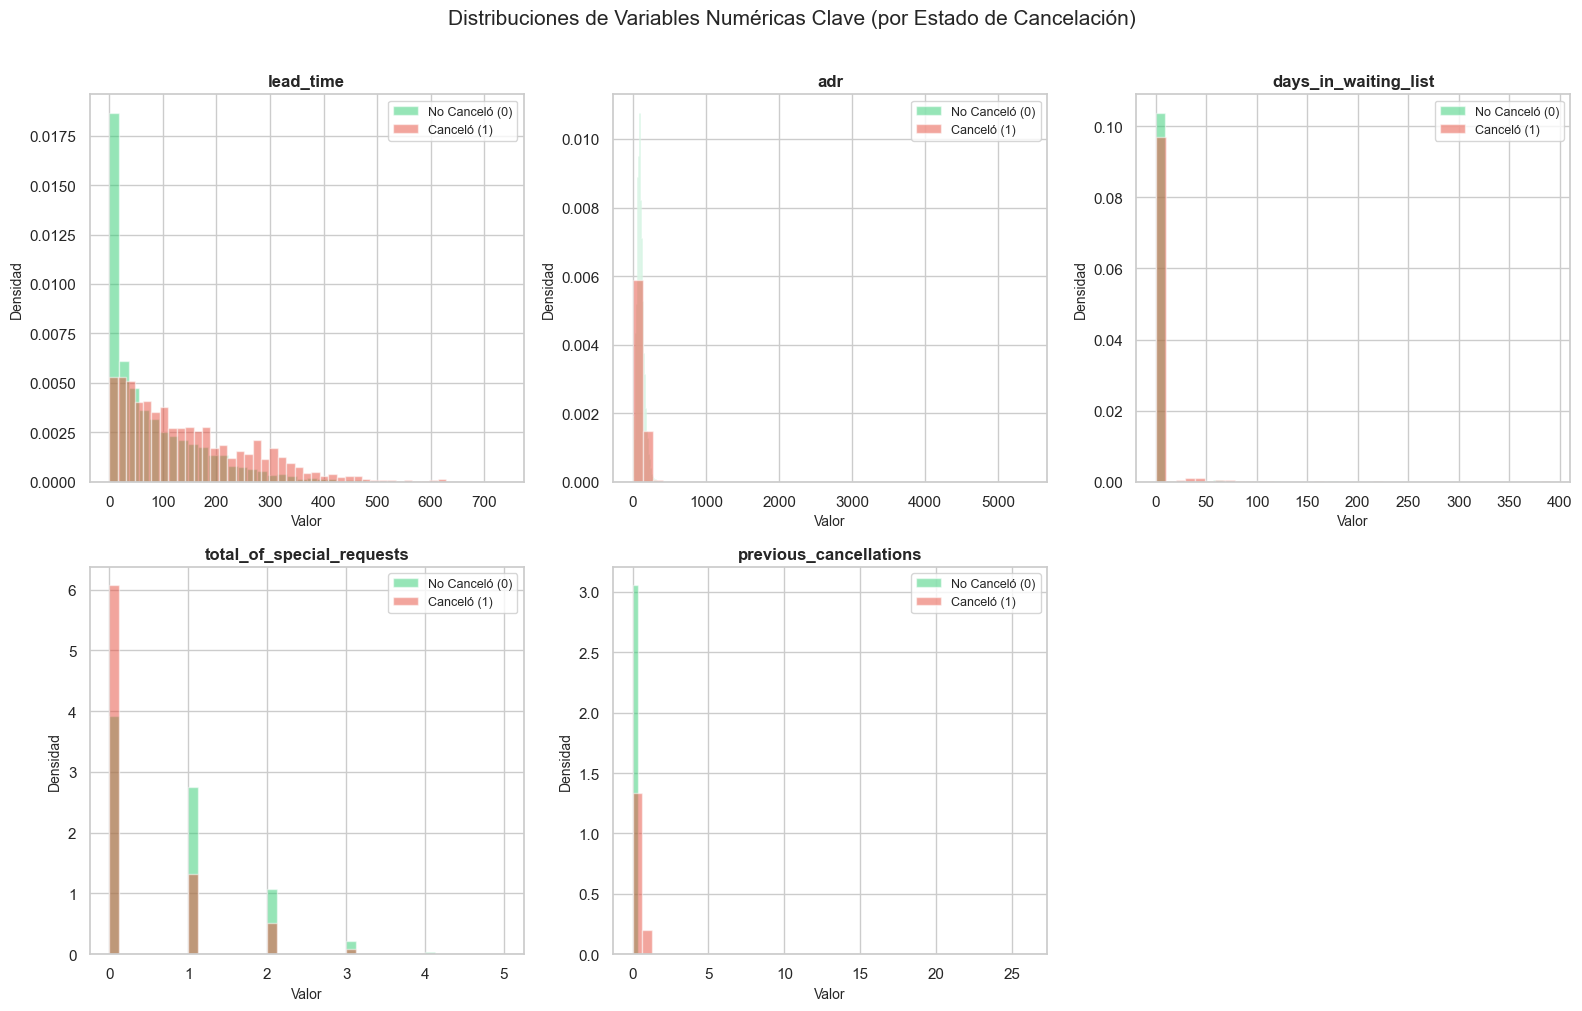

In [14]:
num_features = [
    "lead_time",
    "adr",
    "days_in_waiting_list",
    "total_of_special_requests",
    "previous_cancellations",
]
palette = {0: "#2ecc71", 1: "#e74c3c"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for val, color in palette.items():
        label = "Canceló (1)" if val == 1 else "No Canceló (0)"
        subset = df[df[TARGET_COL] == val][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Valor", fontsize=10)
    axes[i].set_ylabel("Densidad", fontsize=10)
    axes[i].legend(fontsize=9)

# Ocultar el subplot vacío sobrante
axes[-1].set_visible(False)

fig.suptitle(
    "Distribuciones de Variables Numéricas Clave (por Estado de Cancelación)", fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

## 6. Detección Crítica de Fuga de Datos (Target Leakage)

Consiste en meter información del "futuro" en el modelo. 
Analizamos la variable categórica `reservation_status` frente a `is_canceled`.


In [15]:
print("Relación exacta entre 'reservation_status' e 'is_canceled':")
pd.crosstab(df["reservation_status"], df[TARGET_COL])

Relación exacta entre 'reservation_status' e 'is_canceled':


is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


### Diagnóstico:
Como se aprecia en la tabla:
* Si `reservation_status` es `Canceled` o `No-Show`, `is_canceled` es exactamente **1**.
* Si es `Check-Out`, es exactamente **0**.

Esto es una **Fuga de Datos**. En la vida real, cuando llega una reserva nueva, **no sabemos si hará Check-Out o Cancelación en el futuro**. Si dejamos `reservation_status` como variable predictora, el modelo aprenderá una regla inútil: "si dice Canceled, predice 1; si dice Check-Out, predice 0". Sacará un 100% de precisión en nuestro ordenador, pero cuando lo despleguemos en la API para clientes reales, sera cuando comience a fallar. 

**Decisión de Ingeniería**: Las columnas `reservation_status` y `reservation_status_date` **seran eliminadas completamente antes del entrenamiento**.